<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Необходимые функции

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Ellipse



# Определяем функции
def f1(x: np.ndarray) -> float:
    """Квадаратичная функция"""
    return (
        10 * x[0] ** 2
        - 4 * x[0] * x[1]
        + 7 * x[1] ** 2
        - 4 * np.sqrt(5) * (5 * x[0] - x[1])
        - 16
    )

def f2(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 1"""
    return (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def f3(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 15"""
    return 15 * (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def golden_section_search(f, l: float, r: float, eps: float = 10**(-8)) -> float:
    tau = (1 + 5 ** (1/2)) / 2
    x1, x2 = l + (r-l) / (tau + 1), r - (r-l) / (tau + 1)
    y = [f(x1), f(x2)]
    iter = 2
    while (r - l) > eps:
        iter += 1
        if y[0] < y[1]:
            tmp = r

            r = x2
            x2 = x1
            y[1] = y[0]

            x1 = l + (r - l) / (tau + 1)
            y[0] = f(x1)

            if tmp == r:
                break

        else:
            tmp = l

            l = x1
            x1 = x2
            y[0] = y[1]

            x2 = r - (r - l) / (tau + 1)
            y[1] = f(x2)

            if tmp == l:
                break

    return (l + r) / 2, iter




def visualize(res, f, x_limits, y_limits):
    """
    Визуализация метода Розенброка с линиями уровня f(x) = f(x_k) на каждой итерации.

    Параметры:
    res - результат работы rozenbok (содержит историю точек)
    f - целевая функция
    x_limits - границы по x (x_min, x_max)
    y_limits - границы по y (y_min, y_max)
    title - заголовок графика
    """
    history = res[0]
    x_history = np.array([point[0] for point in history])
    y_history = np.array([point[1] for point in history])
    f_history = np.array([f(point) for point in history])  # Значения f(x_k)

    # Создаем общую сетку для линий уровня
    x_grid = np.linspace(x_limits[0], x_limits[1], 400)
    y_grid = np.linspace(y_limits[0], y_limits[1], 400)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = np.array([[f([x, y]) for x in x_grid] for y in y_grid])

    plt.figure(figsize=(10, 8))

    # Рисуем путь оптимизации
    plt.plot(x_history, y_history, 'ko-', markersize=4, linewidth=2, zorder = 4)
    plt.scatter(x_history[0], y_history[0], c='green', s=100, label='Начальное приближение')
    plt.scatter(x_history[-1], y_history[-1], c='red', s=100, label='Точка минимума')

    # Для каждой итерации рисуем линию уровня f(x) = f(x_k)
    for k, (xk, yk, fk) in enumerate(zip(x_history, y_history, f_history)):
        # Чтобы избежать дублирования, рисуем только уникальные уровни
        if k == 0 or not np.isclose(fk, f_history[k-1], atol=1e-6):
          if k <= 5 or k % 20 == 0:
            cs = plt.contour(X, Y, Z, levels=[fk], colors='red', alpha=0.5)




    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.xlim(x_limits)
    plt.ylim(y_limits)
    plt.show()

In [ ]:
# @title Реализация методов
def golden_ratio(f,  a: float, b: float, eps:float) -> list:
    # возвращаем точку минимума, значение минимума, количество итераций, количество вызовов функции, интервалы неопределенности

    tau = (1 + np.sqrt(5)) / 2

    xk1 = a + (1 - 1/tau)*(b - a)
    xk2 = a + (1/tau) * (b-a)

    iterations = 1
    f_calls = 0
    a_prev = a
    b_prev = b
    a_next =  a
    b_next = b
    left = [a]
    right = [b]

    fk1 = f(xk1)
    fk2 = f(xk2)
    f_calls += 2

    lenght = [b-a]

    while (b_next - a_next) > eps:
        iterations += 1

        a_prev = a_next
        b_prev = b_next



        if (fk1 <= fk2):
            a_next = a_prev
            b_next = xk2
            xk2 = xk1
            fk2 = fk1
            xk1 = a_next + (1 - 1/tau) * (b_next - a_next)
            fk1 = f(xk1)
            f_calls += 1

        else:
            a_next = xk1
            b_next = b_prev
            fk1  = fk2
            xk1 = xk2
            xk2 = a_next + (1/tau) * (b_next - a_next)
            fk2 = f(xk2)
            f_calls += 1

        left += [a_next]
        right += [b_next]
        lenght += [b_next - a_next]

    if (fk1 < fk2):
        return [a_next, fk1, iterations, f_calls, left, right]
    return [b_next, fk2, iterations, f_calls, left, right]

def cps(x0, f, eps, l):
    x_next = x_prev = x0
    f_calls = 1
    iterations = 0
    f_trace = [f(x0)]
    trace_midpoints = [x0]
    x_mid = x_prev
    n = x0.__len__()

    while iterations == 0 or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next-x_prev) > eps):
        x_prev = x_next
        x_mid = x_prev
        for i in range(n):
            e = np.zeros(n)
            e[i] = 1
            phi = lambda kappa: f(x_mid + kappa*e)
            golden_ratio_res = golden_ratio(phi, -l, l, eps*1e-3)
            cur_kappa = golden_ratio_res[0]
            f_calls += golden_ratio_res[3]
            x_mid = x_mid + cur_kappa*e
            trace_midpoints += [x_mid]
        x_next = x_mid
        # trace_midpoints += [x_mid]
        f_trace += [f(x_next)]
        f_calls += 1
        iterations += 1


    return [trace_midpoints, x0, eps, iterations, f_calls, x_next, f_trace[-1]]


def hook_jivs(x0, f, eps, l, b = np.array([1,1]),  gamma = 2):
    x_next = x_prev = x0
    b_st = b
    f_calls = 1
    iterations = 0
    f_trace = [f(x0)]
    x_mid = x_prev
    trace = [x0]
    n = x0.__len__()
    flag = False
    while iterations == 0 or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next-x_prev) > eps)  or flag :
        flag = False
        x_prev = x_next
        x_mid = x_prev
        x_mid_prev = x_mid
        for i in range(n):
            e = np.zeros(n)
            e[i] = 1
            f_mid_plus = f(x_mid + b[i]*e)
            f_mid_minus = f(x_mid - b[i]*e)
            f_mid = f(x_mid)
            f_calls += 3
            if (f_mid_plus < f_mid) and (f_mid_plus <= f_mid_minus):
                x_mid = x_mid + b[i]*e
            elif (f_mid_minus < f_mid) and (f_mid_minus < f_mid_plus):
                x_mid = x_mid - b[i]*e
        if (np.linalg.norm(x_mid - x_mid_prev) < 1e-15):
            b = b* 1/ gamma
            x_mid = x_mid_prev
            flag = True
            continue
        b = b_st
        phi = lambda kappa: f(x_prev + (x_mid - x_prev)*kappa)
        golden_ratio_res = golden_ratio(phi, 0, l, eps*1e-3)
        cur_kappa = golden_ratio_res[0]
        # golden_ratio_res = golden_ratio(phi, cur_kappa-0.5, cur_kappa+0.5, eps*0.001)
        # cur_kappa = golden_ratio_res[0]
        f_calls += golden_ratio_res[3]
        x_next = x_prev + (x_mid - x_prev)*cur_kappa
        f_trace += [f(x_next)]
        f_calls += 1
        trace += [x_next]
        iterations += 1

    return [trace, x0, eps, iterations, f_calls, x_next, f_trace[-1]]


def rozenbok(x0, f, eps, l):
    x_next = x_prev = x0
    f_calls = 1
    iterations = 0
    f_trace = [f(x0)]
    trace_midpoints = [x0]
    x_mid = x_prev
    trace = [x0]
    n = x0.__len__()
    b = np.array([0.1,0.1])
    b_st = b
    gamma = 2
    u = []
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1
        u += [e]
    flag = False
    while iterations == 0 or flag or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next - x_prev) > eps):
        flag = False
        x_prev = x_next
        x_mid = x_prev

        for i in range(n):
            phi = lambda kappa: f(x_mid + kappa*u[i])
            golden_ratio_res = golden_ratio(phi, -l, l, eps*0.001)
            f_calls+=golden_ratio_res[2]
            # f_mid = f(x_mid)
            # f_mid_plus = f(x_mid + b[i]*u[i])
            # f_mid_minus = f(x_mid - b[i]*u[i])
            # print("f_mid_plus", f_mid_plus, "x_plus = ", x_mid + b[i]*e)
            # print("f_mid_minus", f_mid_minus, "x_minus =", x_mid - b[i]*e)
            # print("f_mid", f_mid, "xmid = ", x_mid)
            cur_kappa = golden_ratio_res[0]
            # f_calls += 3
            x_mid = x_mid + cur_kappa*u[i]
            # if f_mid_plus < f_mid and f_mid_plus <= f_mid_minus:
            #     x_mid = x_mid + b[i]*u[i]
            # elif f_mid_minus < f_mid and f_mid_minus < f_mid_plus:
            #     x_mid = x_mid - b[i]*u[i]
            trace += [x_mid]
        # phi = lambda kappa: f(x_prev + (x_mid - x_prev)*kappa)
        # golden_ratio_res = golden_ratio(phi, 0, 20, eps*0.1)
        cur_kappa = golden_ratio_res[0]
        f_calls += golden_ratio_res[2]
        x_next = x_mid
        # x_next = x_prev + (x_mid - x_prev)*cur_kappa
        f_trace += [f(x_next)]
        f_calls += 1
        # trace += [x_next]
        iterations += 1
        cur_u = x_next - x_prev
        u = [cur_u, np.array([-cur_u[1], cur_u[0]])]




    return [trace, x0, eps, iterations, f_calls, x_next, f_trace[-1]]

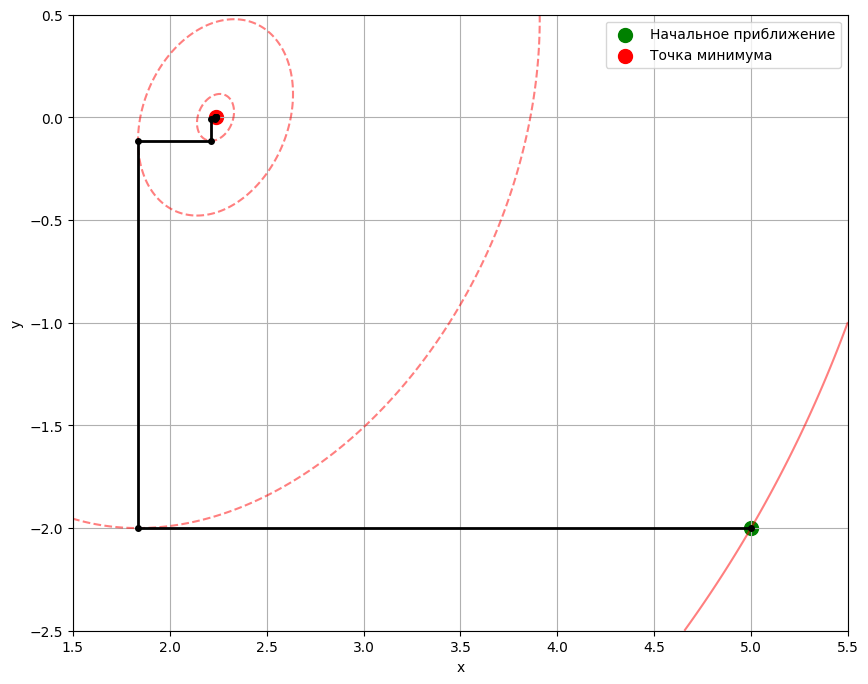

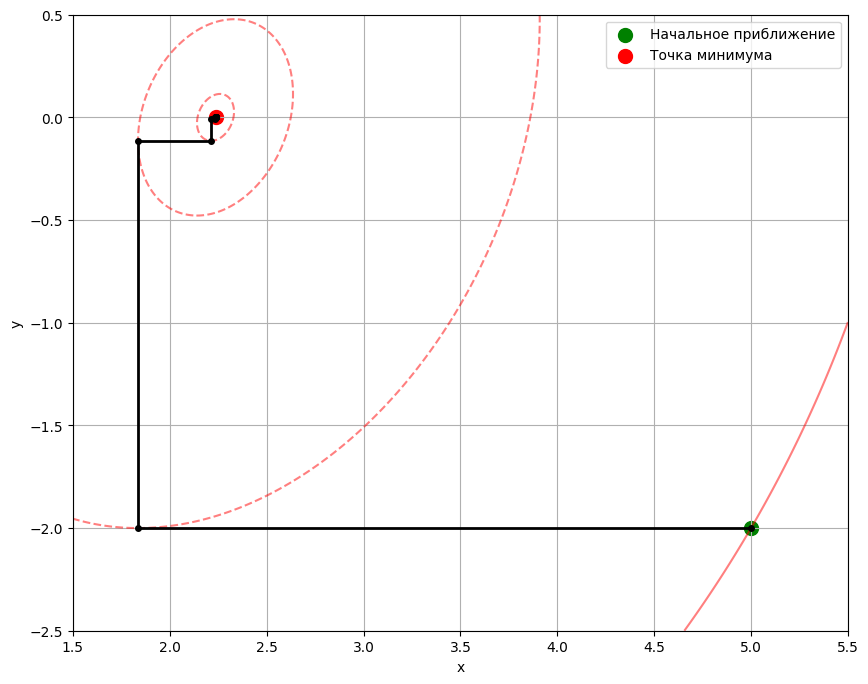

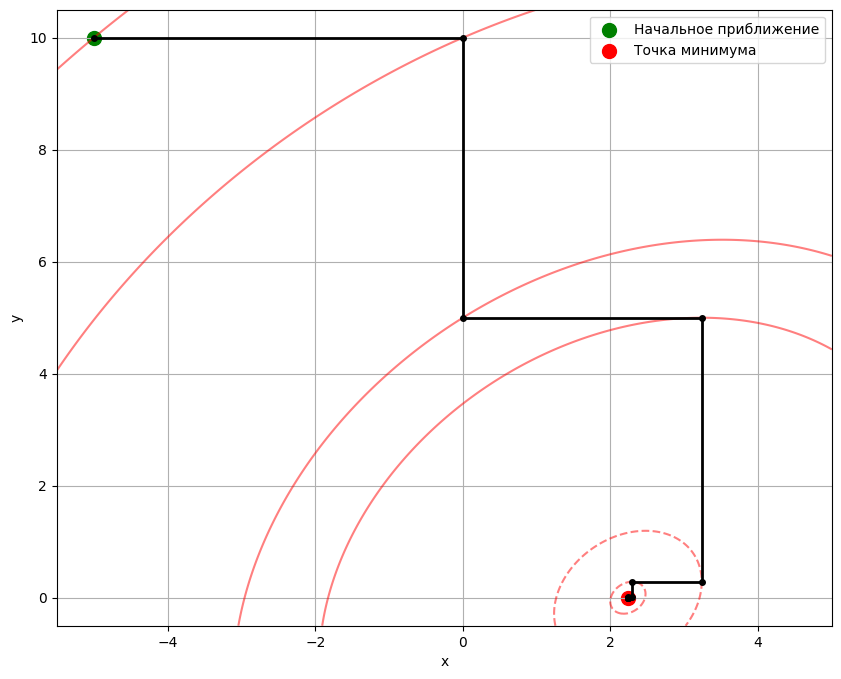

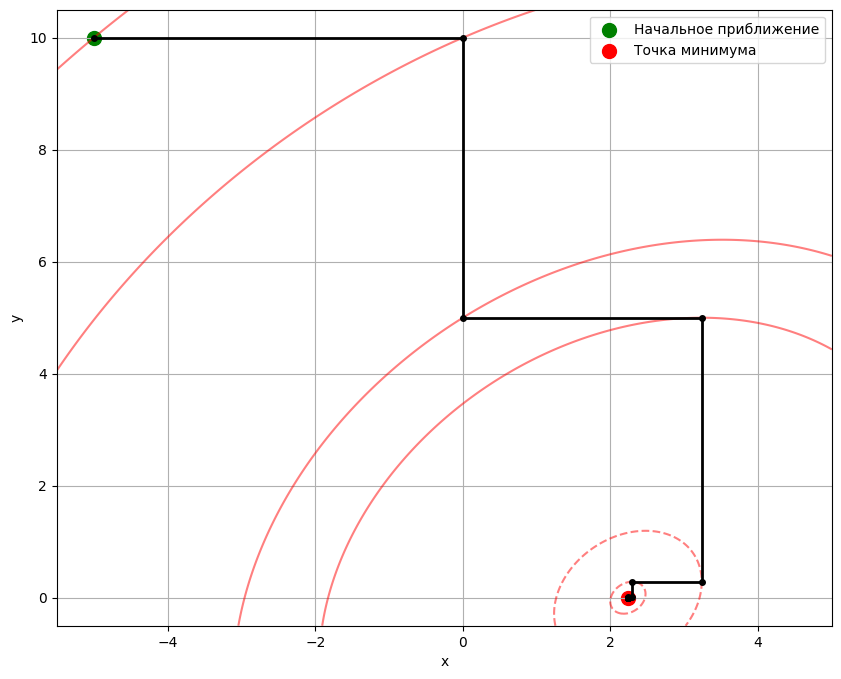

/tmp/ipython-input-61-3032531864.py:100: RuntimeWarning: divide by zero encountered in scalar divide
  while iterations == 0 or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next-x_prev) > eps)  or flag :


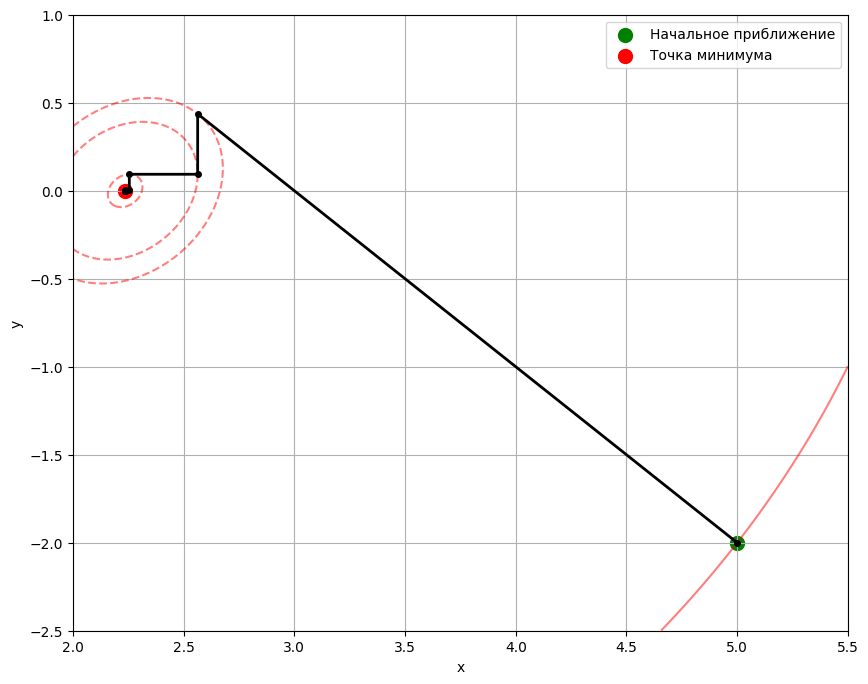

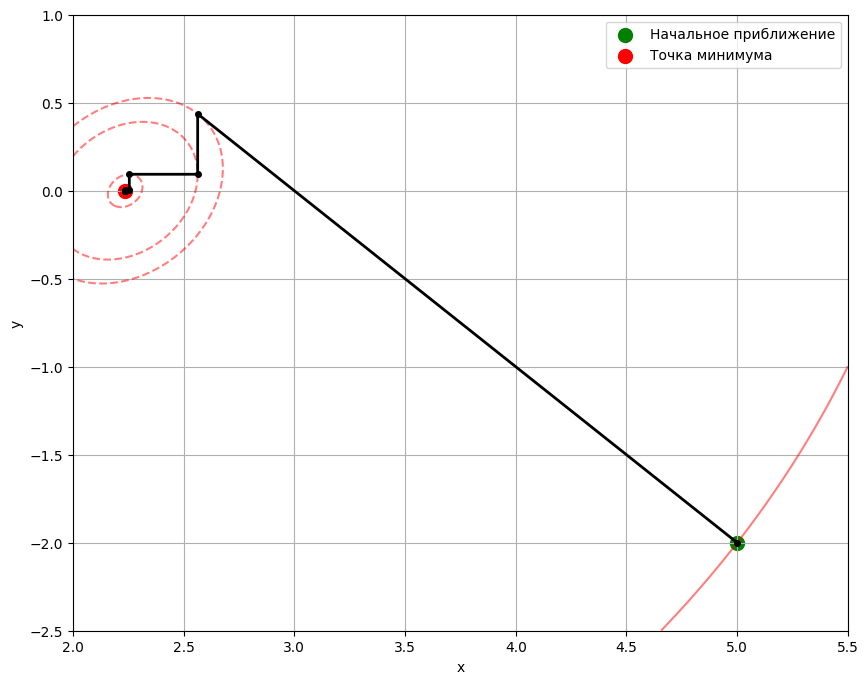

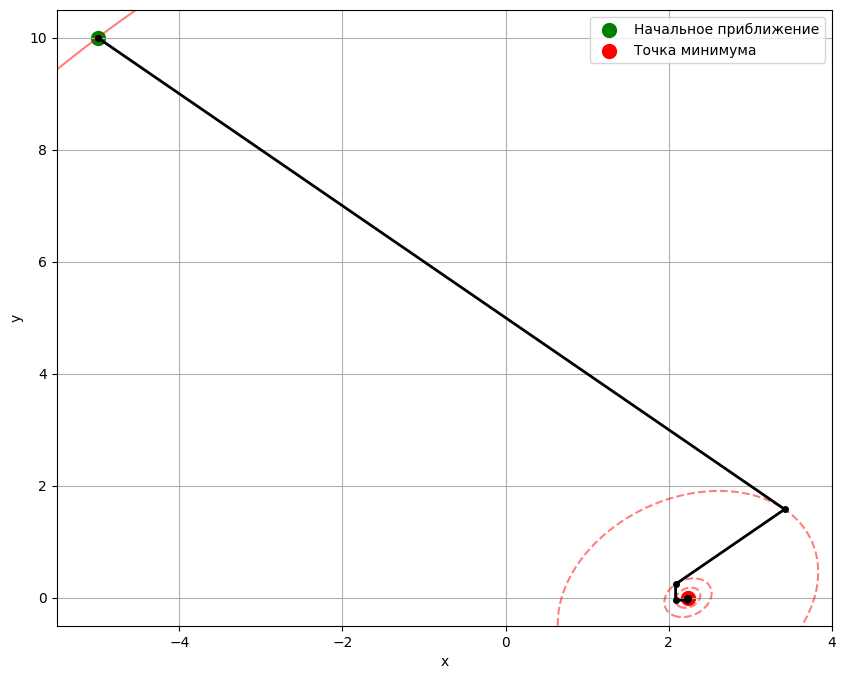

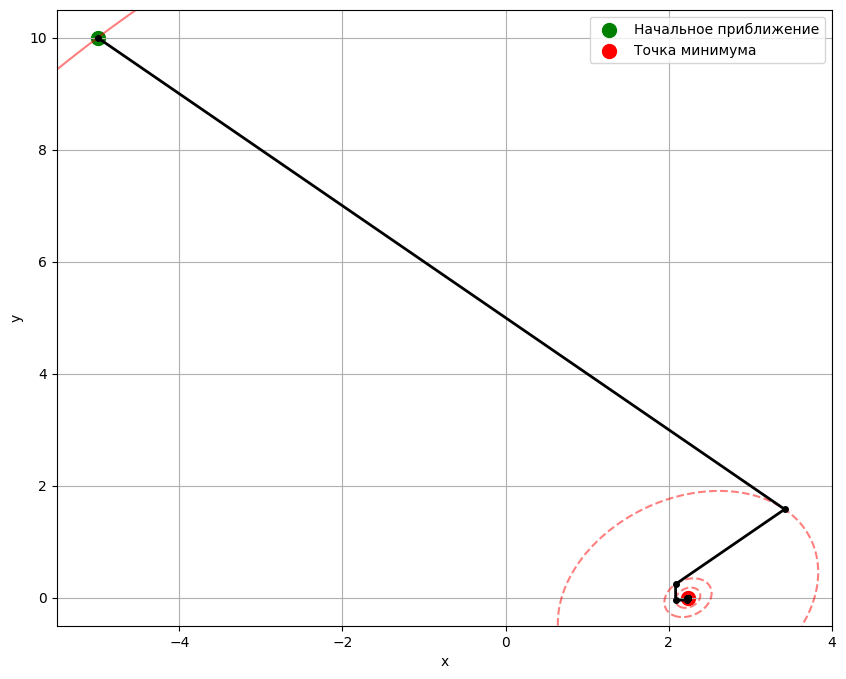

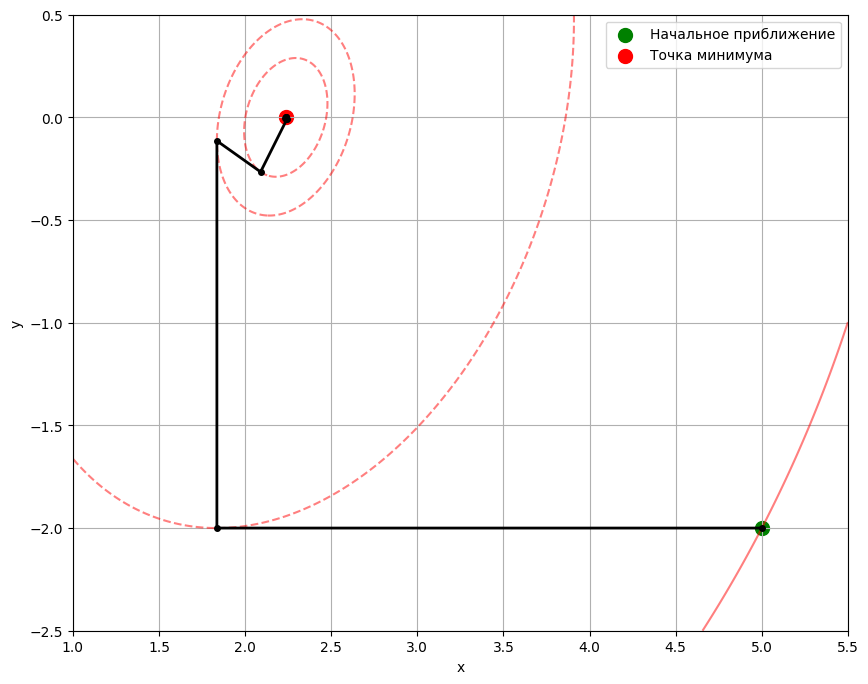

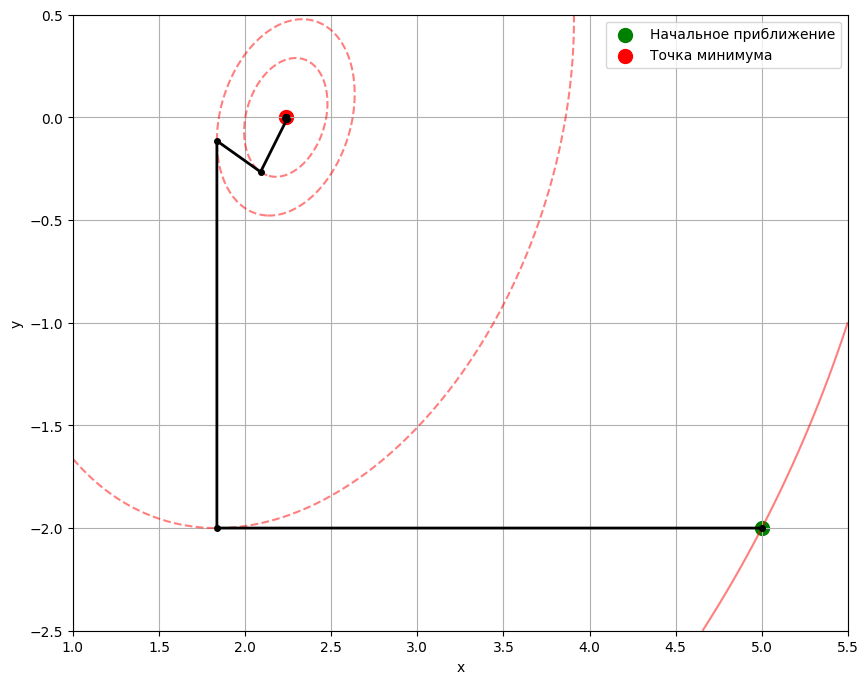

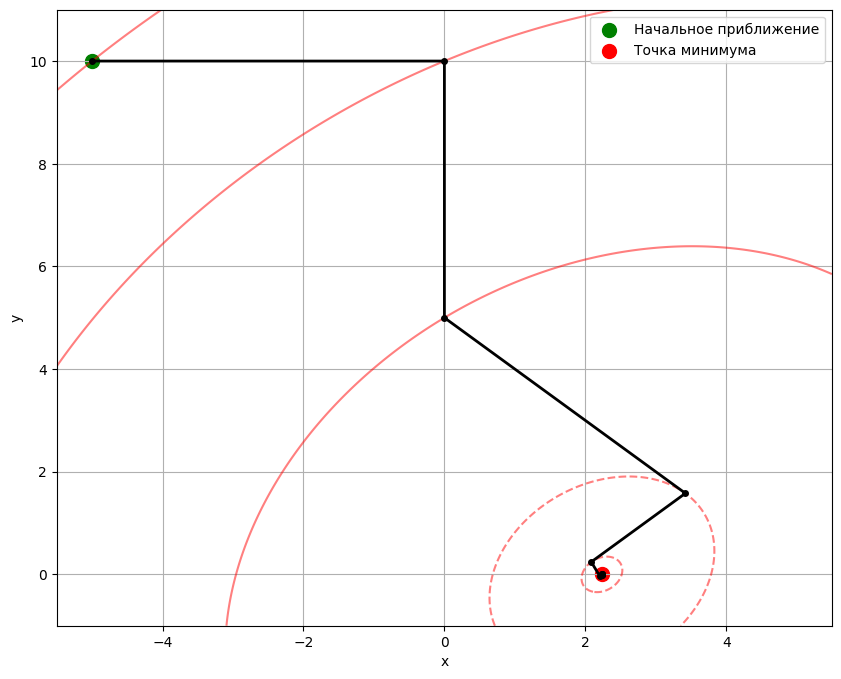

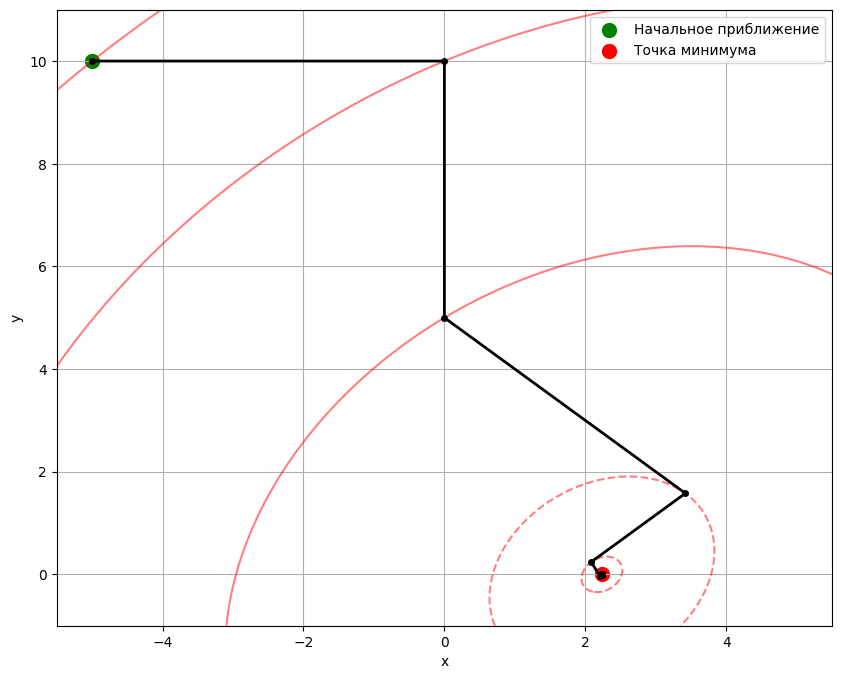

In [ ]:
# @title Методы для квадратичной

x1 = [5.0, -2.0]
eps1 = 1e-2

x2 = [-5.0, 10.0]
eps2 = 1e-5

cps_q_1 = cps(x1, f1, eps1,5)
visualize(cps_q_1, f1, [1.5,5.5], [-2.5,0.5])
cps_q_2 = cps(x1, f1, eps2,5)
visualize(cps_q_2, f1, [1.5,5.5], [-2.5,0.5])
cps_q_3 = cps(x2, f1, eps1,5)
visualize(cps_q_3, f1, [-5.5,5], [-0.5,10.5])
cps_q_4 = cps(x2, f1, eps2,5)
visualize(cps_q_4, f1, [-5.5,5], [-0.5,10.5])


hj_q_1 = hook_jivs(x1, f1, eps1,10)
visualize(hj_q_1, f1, [2,5.5], [-2.5,1])
hj_q_2 = hook_jivs(x1, f1, eps2,10)
visualize(hj_q_2, f1, [2,5.5], [-2.5,1])
hj_q_3 = hook_jivs(x2, f1, eps1,10)
visualize(hj_q_3, f1, [-5.5,4], [-0.5,10.5])
hj_q_4 = hook_jivs(x2, f1, eps2,10)
visualize(hj_q_4, f1, [-5.5,4], [-0.5,10.5])


r_q_1 = rozenbok(x1, f1, eps1,5)
visualize(r_q_1, f1, [1,5.5], [-2.5,0.5])
r_q_2 = rozenbok(x1, f1, eps2,5)
visualize(r_q_2, f1, [1,5.5], [-2.5,0.5])
r_q_3 = rozenbok(x2, f1, eps1,5)
visualize(r_q_3, f1, [-5.5,5.5], [-1,11])
r_q_4 = rozenbok(x2, f1, eps2,5)
visualize(r_q_4, f1, [-5.5,5.5], [-1,11])

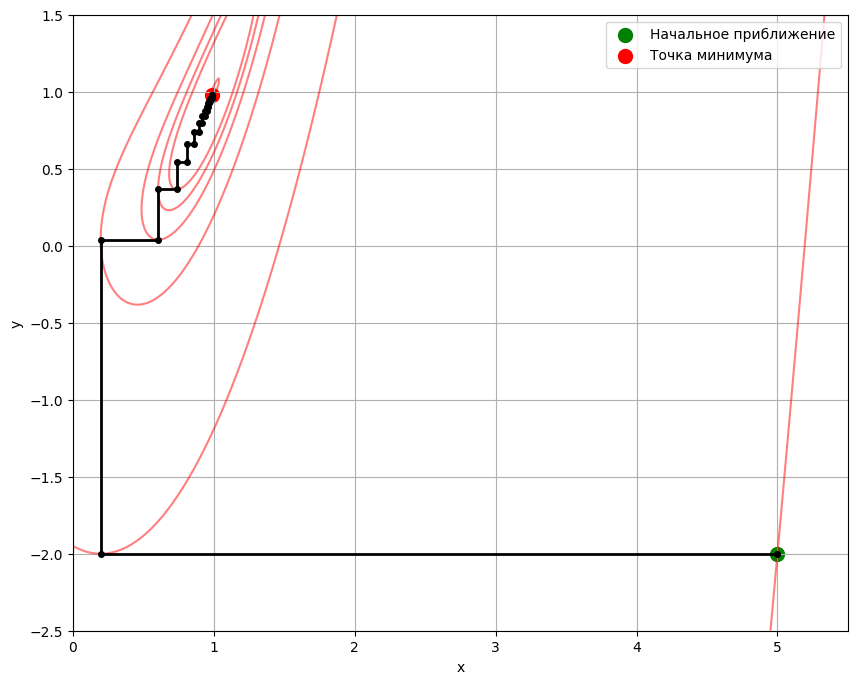

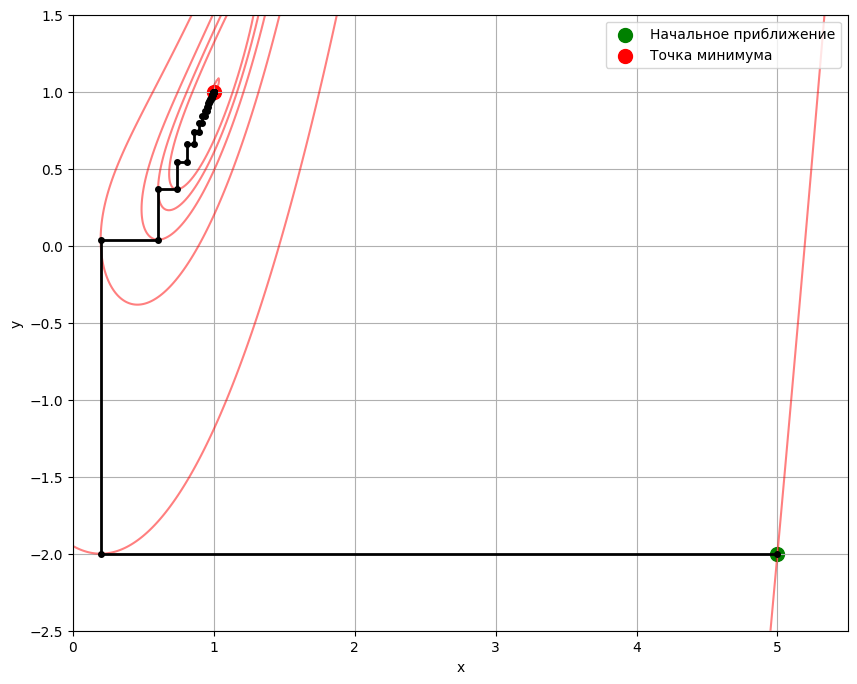

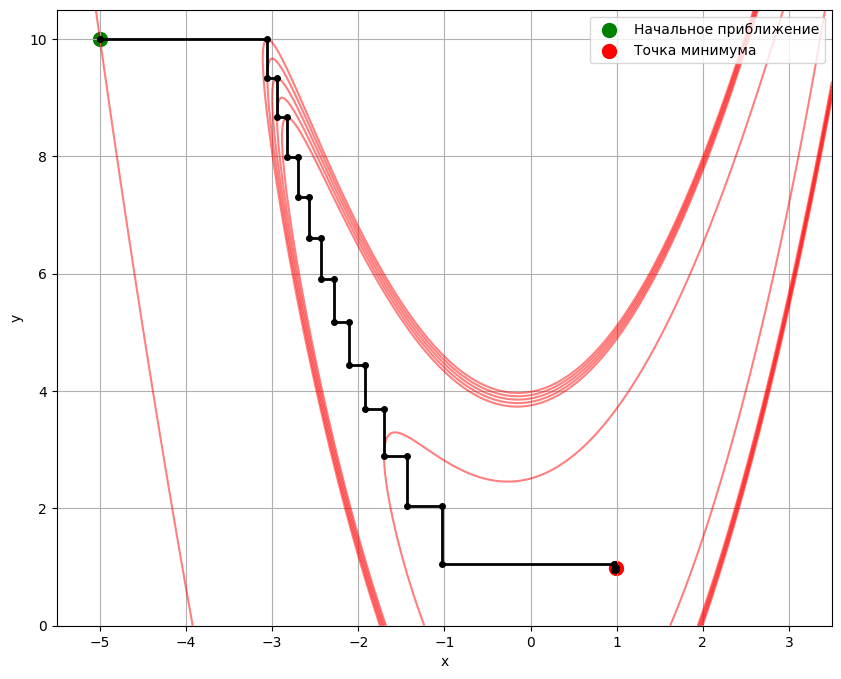

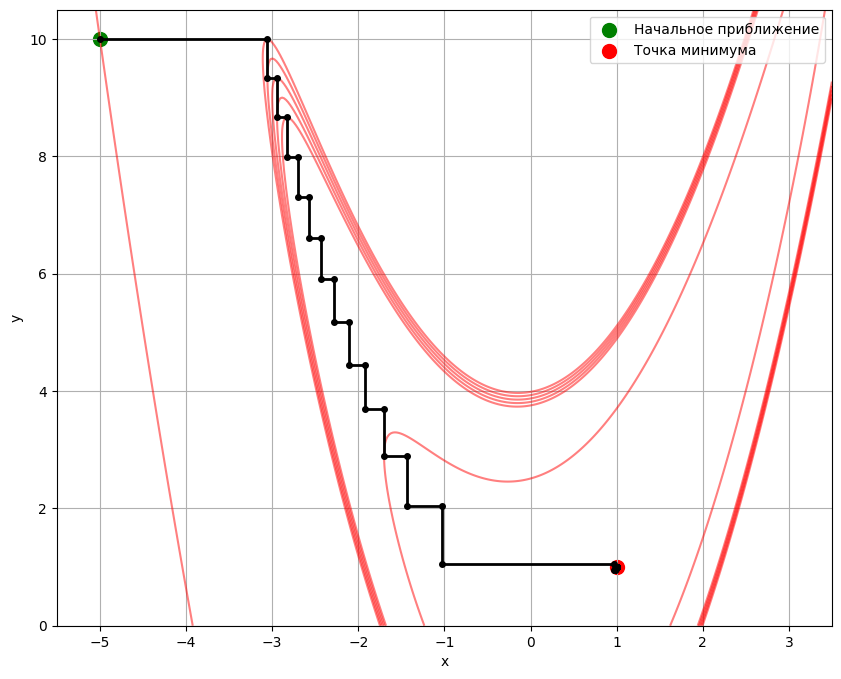

/tmp/ipython-input-61-3032531864.py:100: RuntimeWarning: divide by zero encountered in scalar divide
  while iterations == 0 or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next-x_prev) > eps)  or flag :


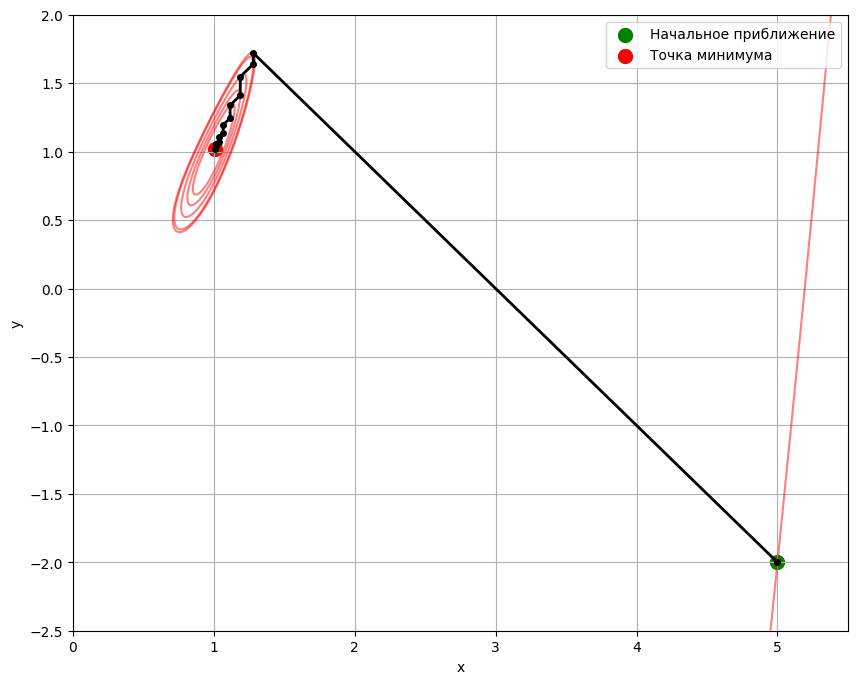

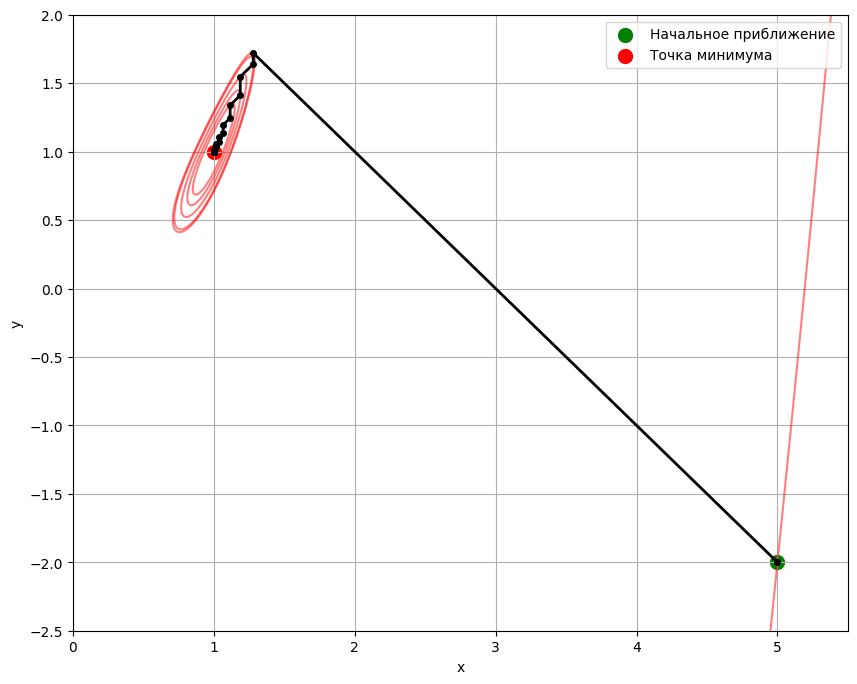

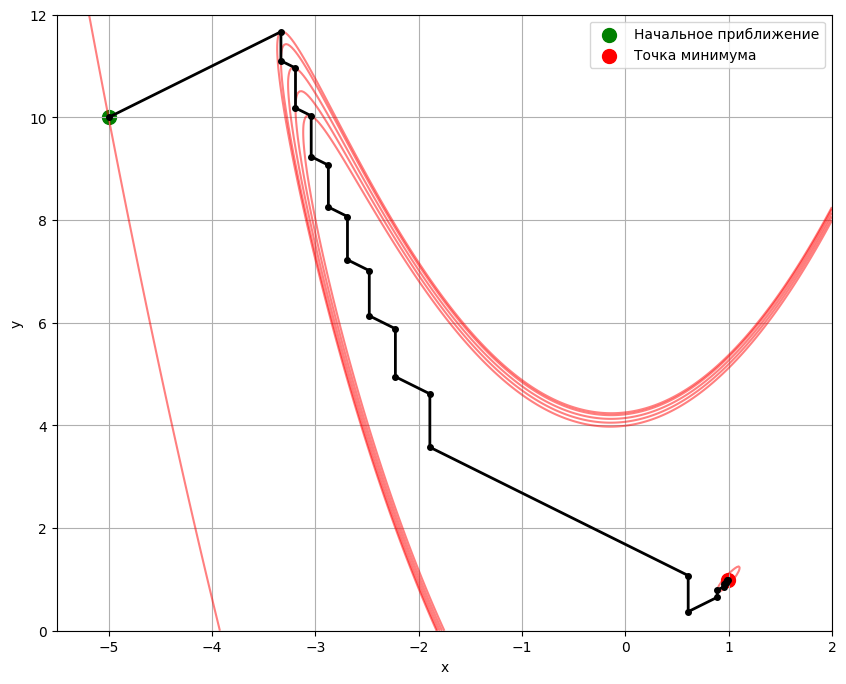

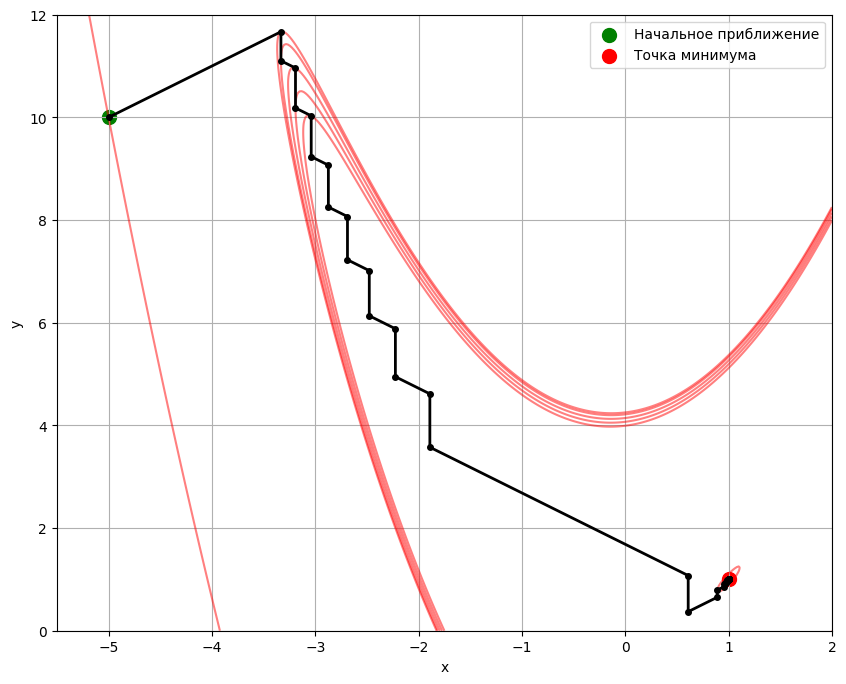

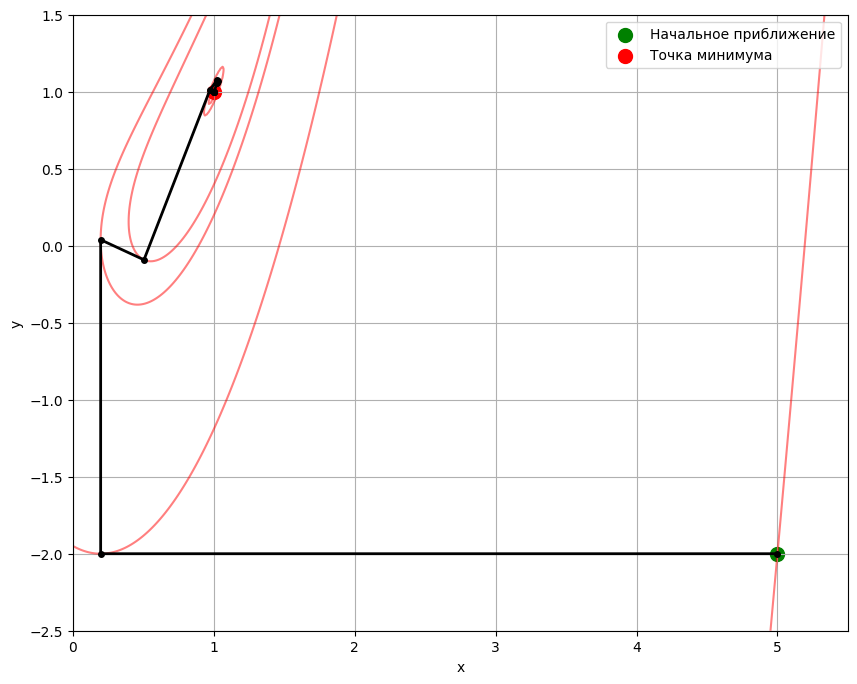

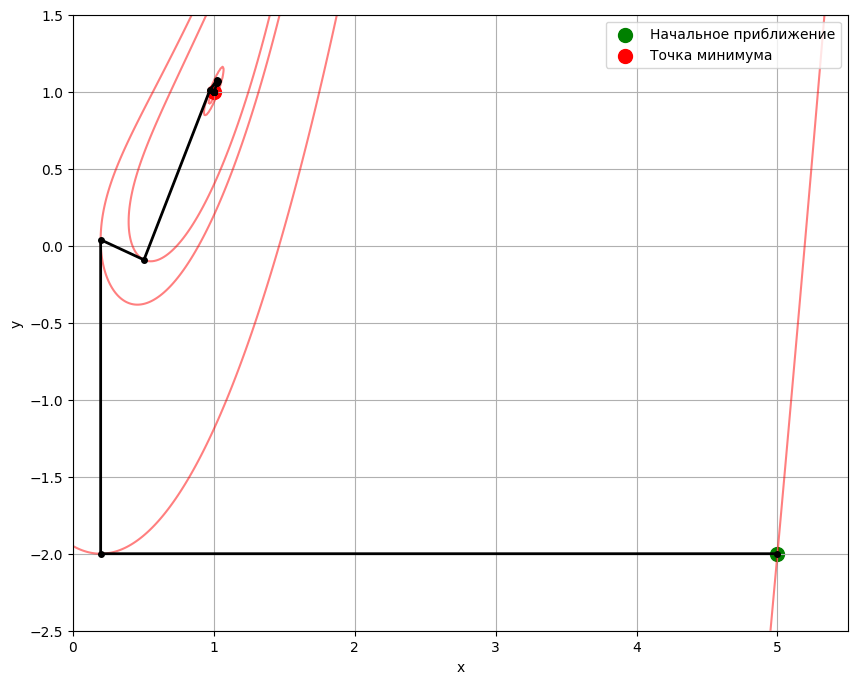

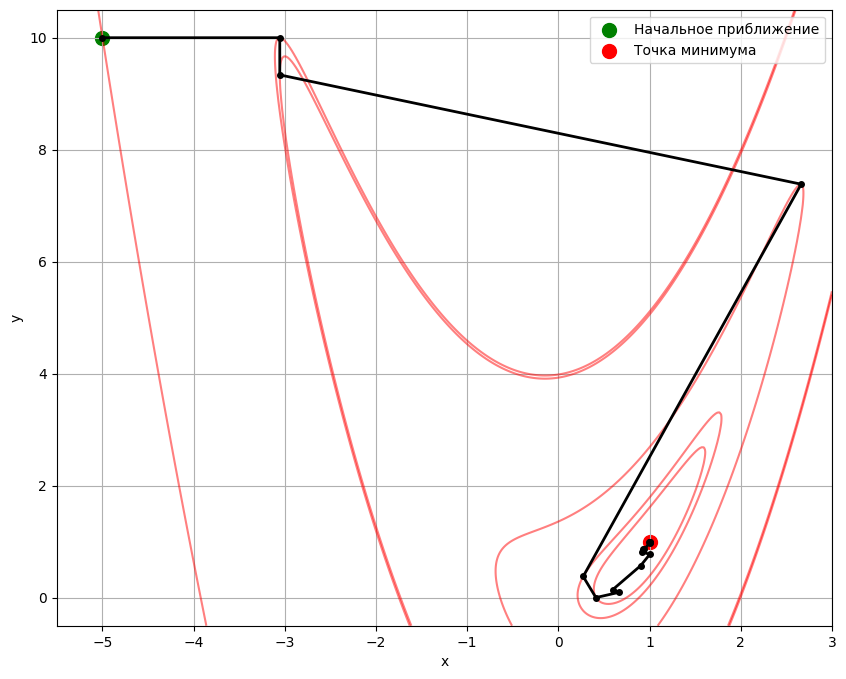

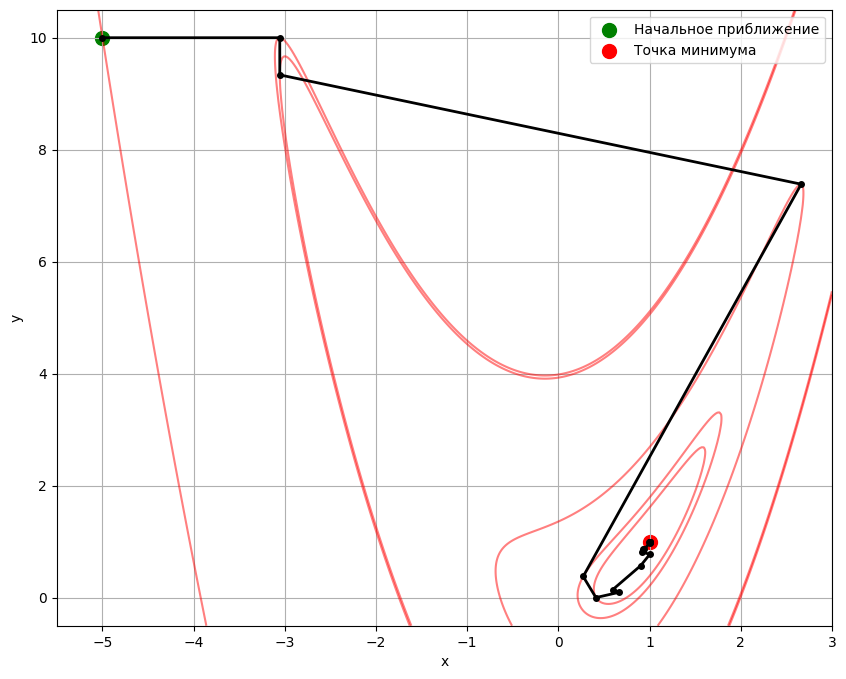

In [ ]:
# @title Методы для Розенброка 1

x1 = [5.0, -2.0]
eps1 = 1e-2

x2 = [-5.0, 10.0]
eps2 = 1e-5

cps_r1_1 = cps(x1, f2, eps1,10)
visualize(cps_r1_1, f2, [0,5.5], [-2.5,1.5])
cps_r1_2 = cps(x1, f2, eps2,10)
visualize(cps_r1_2, f2, [0,5.5], [-2.5,1.5])
cps_r1_3 = cps(x2, f2, eps1,2)
visualize(cps_r1_3, f2, [-5.5,3.5], [0,10.5])
cps_r1_4 = cps(x2, f2, eps2,2)
visualize(cps_r1_4, f2, [-5.5,3.5], [0,10.5])

hj_r1_1 = hook_jivs(x1, f2, eps1,4)
visualize(hj_r1_1, f2, [0,5.5], [-2.5,2])
hj_r1_2 = hook_jivs(x1, f2, eps2,4)
visualize(hj_r1_2, f2, [0,5.5], [-2.5,2])
hj_r1_3 = hook_jivs(x2, f2, eps1,10)
visualize(hj_r1_3, f2, [-5.5,2], [0,12])
hj_r1_4 = hook_jivs(x2, f2, eps2,10)
visualize(hj_r1_4, f2, [-5.5,2], [0,12])


r_r1_1 = rozenbok(x1, f2, eps1, 5)
visualize(r_r1_1, f2, [0,5.5], [-2.5,1.5])
r_r1_2 = rozenbok(x1, f2, eps2, 5)
visualize(r_r1_2, f2, [0,5.5], [-2.5,1.5])
r_r1_3 = rozenbok(x2, f2, eps1,6)
visualize(r_r1_3, f2, [-5.5,3], [-0.5,10.5])
r_r1_4 = rozenbok(x2, f2, eps2,6)
visualize(r_r1_4, f2, [-5.5,3], [-0.5,10.5])

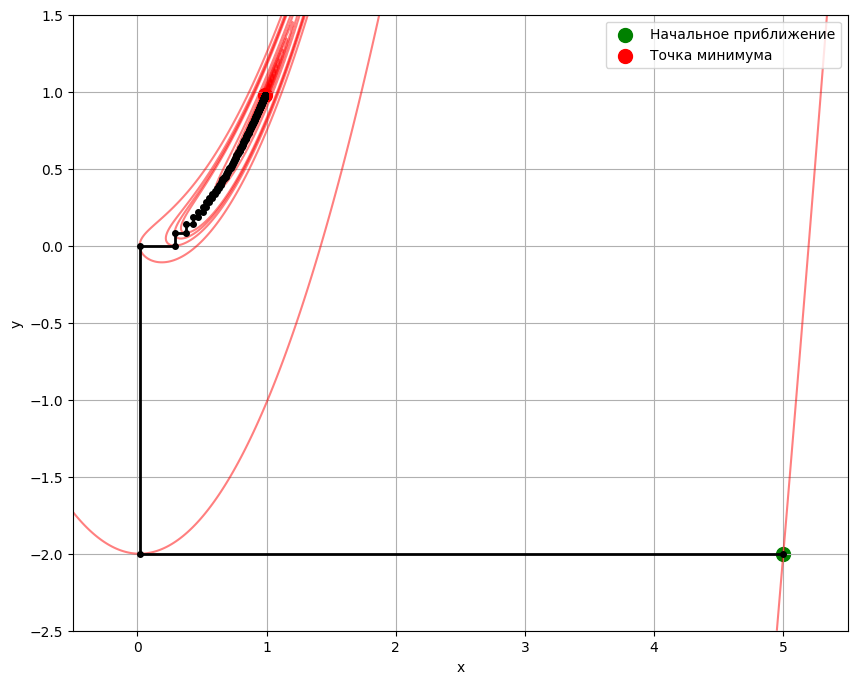

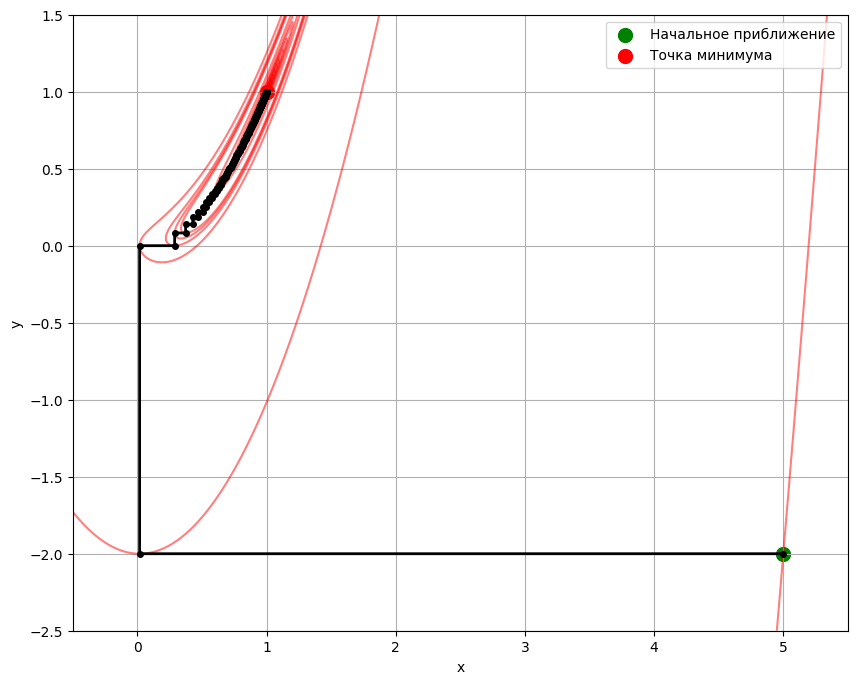

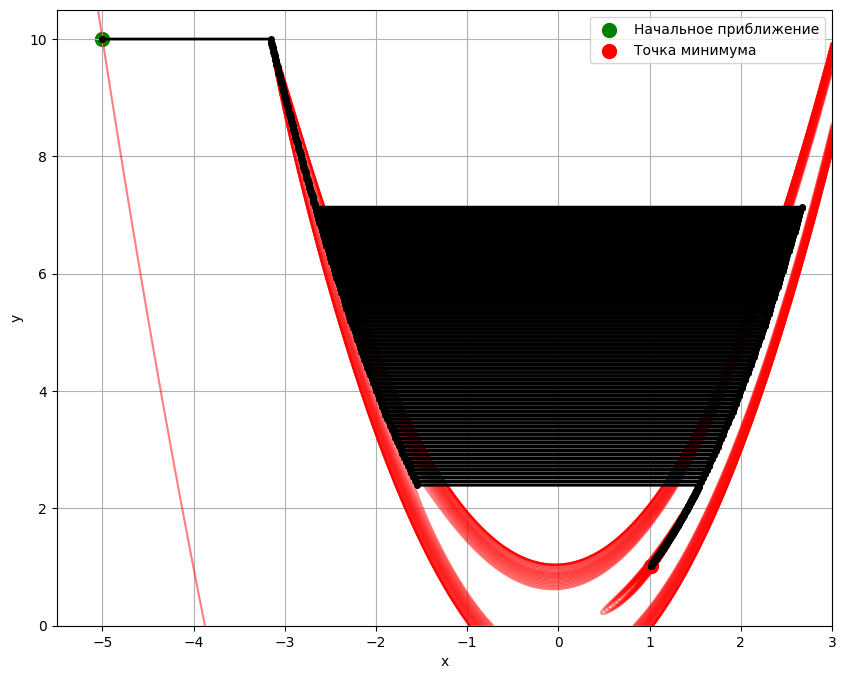

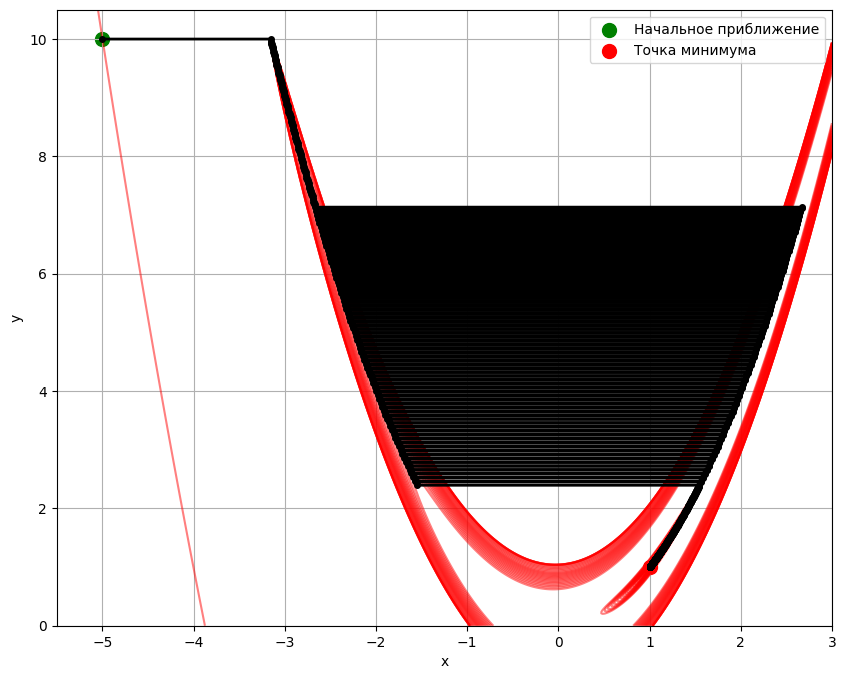

/tmp/ipython-input-61-3032531864.py:100: RuntimeWarning: divide by zero encountered in scalar divide
  while iterations == 0 or (np.linalg.norm(f_trace[-1] - f_trace[-2])/np.linalg.norm(x_next-x_prev) > eps)  or flag :


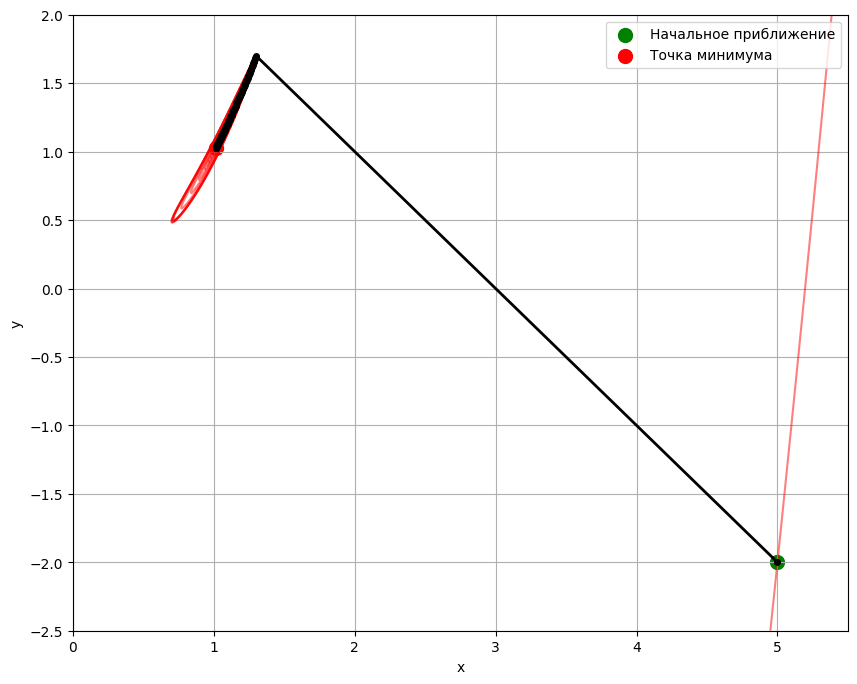

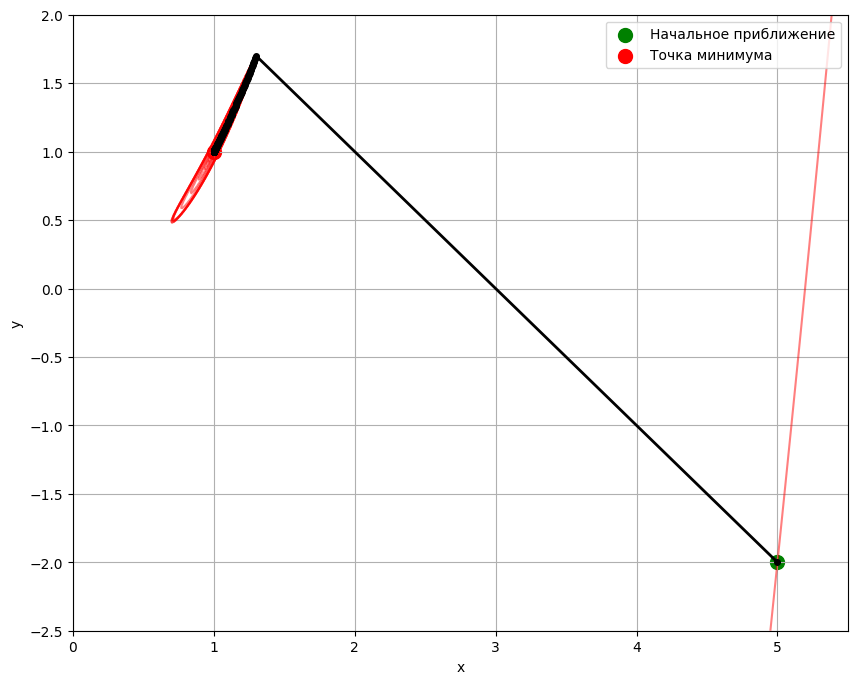

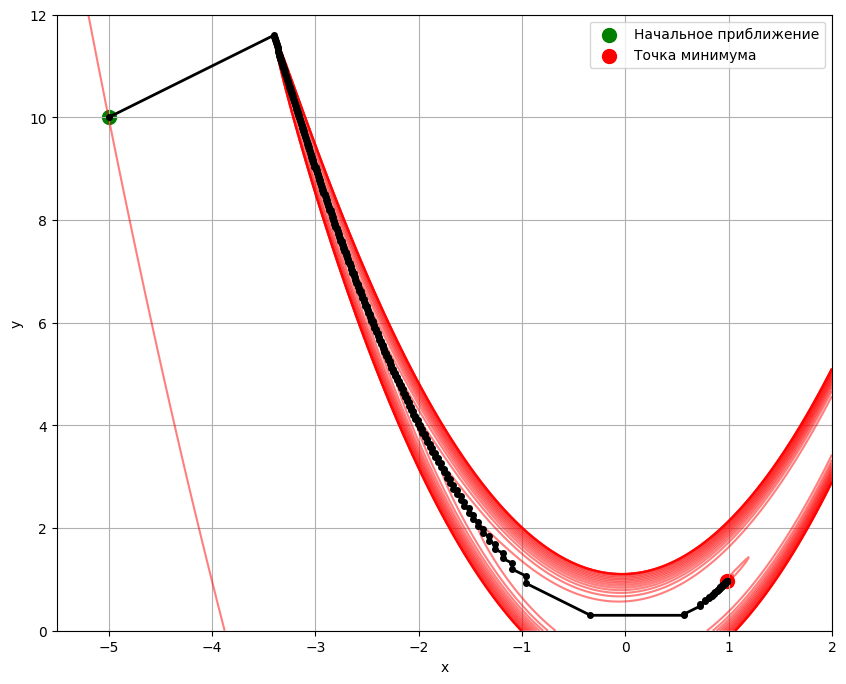

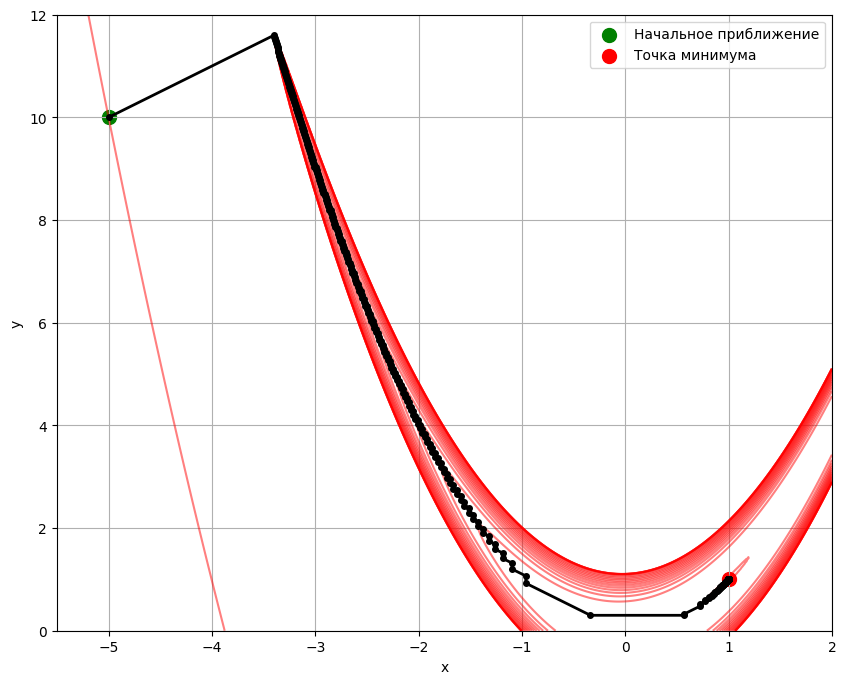

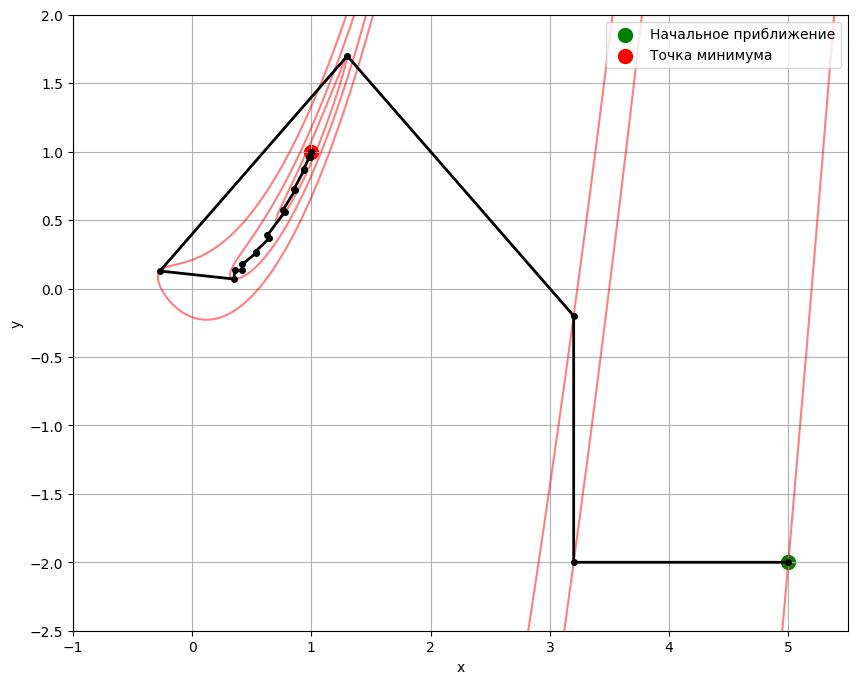

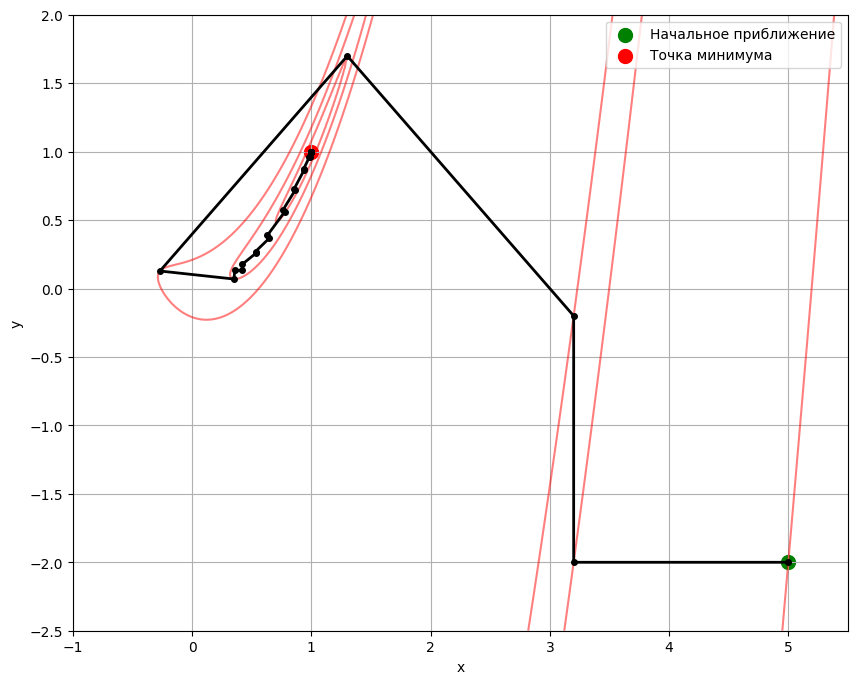

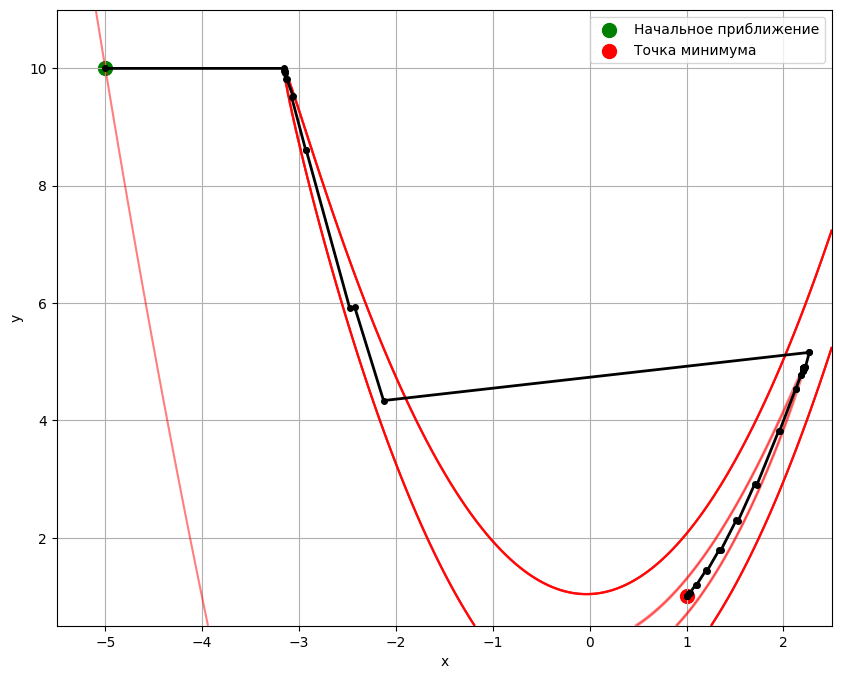

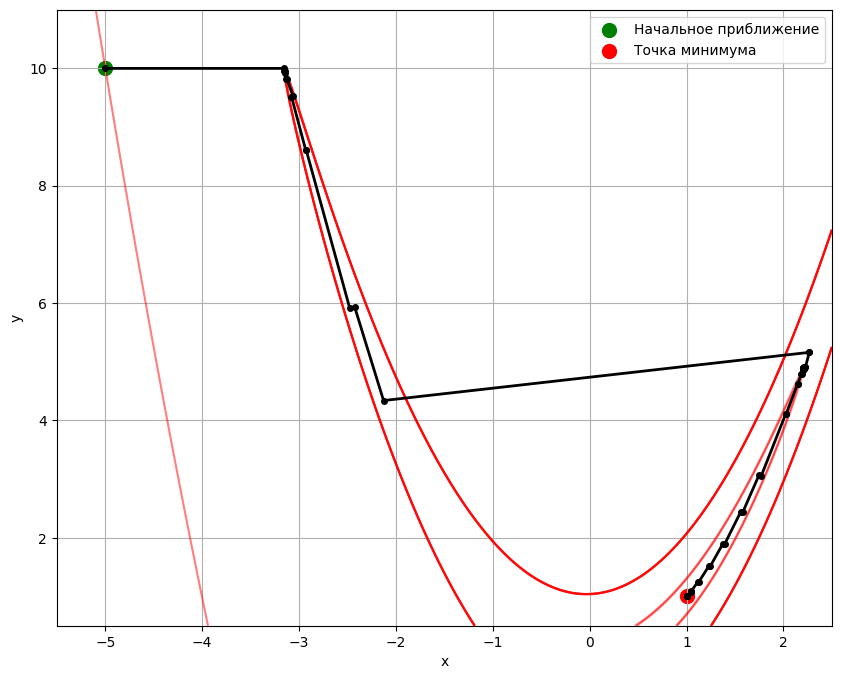

In [ ]:
# @title Методы для Розенброка 15

cps_r15_1 = cps(x1, f3, eps1,5)
visualize(cps_r15_1, f3, [-0.5,5.5], [-2.5,1.5])
cps_r15_2 = cps(x1, f3, eps2,5)
visualize(cps_r15_2, f3, [-0.5,5.5], [-2.5,1.5])
cps_r15_3 = cps(x2, f3, eps1,7)
visualize(cps_r15_3, f3, [-5.5,3], [0,10.5])
cps_r15_4 = cps(x2, f3, eps2,7)
visualize(cps_r15_4, f3, [-5.5,3], [0,10.5])

hj_r15_1 = hook_jivs(x1, f3, eps1,10)
visualize(hj_r15_1, f3, [0,5.5], [-2.5,2])
hj_r15_2 = hook_jivs(x1, f3, eps2,10)
visualize(hj_r15_2, f3, [0,5.5], [-2.5,2])
hj_r15_3 = hook_jivs(x2, f3, eps1,10)
visualize(hj_r15_3, f3, [-5.5,2], [0,12])
hj_r15_4 = hook_jivs(x2, f3, eps2,10)
visualize(hj_r15_4, f3, [-5.5,2], [0,12])


r_r15_1 = rozenbok(x1, f3, eps1,1.8)
visualize(r_r15_1, f3, [-1,5.5], [-2.5,2])
r_r15_2 = rozenbok(x1, f3, eps2,1.8)
visualize(r_r15_2, f3, [-1,5.5], [-2.5,2])
r_r15_3 = rozenbok(x2, f3, eps1,3)
visualize(r_r15_3, f3, [-5.5,2.5], [0.5,11])
r_r15_4 = rozenbok(x2, f3, eps2,3)
visualize(r_r15_4, f3, [-5.5,2.5], [0.5,11])

In [ ]:
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["ЦПС","ЦПС","ЦПС","ЦПС","Хук-Дживс","Хук-Дживс","Хук-Дживс","Хук-Дживс","Розенброк","Розенброк","Розенброк","Розенброк"]
data = [cps_q_1[1:],cps_q_2[1:], cps_q_3[1:], cps_q_4[1:], hj_q_1[1:],hj_q_2[1:], hj_q_3[1:], hj_q_4[1:], r_q_1[1:],r_q_2[1:],r_q_3[1:],r_q_4[1:]]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-----------+-------------------------+-------+-------------------+-------------------+-----------------------------------+------------------------+
|           | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии | Найденная точка минимума          |   Найденное знач. ф-ии |
+===========+=========================+=======+===================+===================+===================================+========================+
| ЦПС       | [5.0, -2.0]             | 0.01  |                 5 |               316 | [ 2.23606713e+00 -3.66550252e-06] |                    -66 |
+-----------+-------------------------+-------+-------------------+-------------------+-----------------------------------+------------------------+
| ЦПС       | [5.0, -2.0]             | 1e-05 |                 7 |               652 | [ 2.23606792e+00 -5.64919069e-08] |                    -66 |
+-----------+-------------------------+-------+-------------------+-------------------+-------------------

In [ ]:
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["ЦПС","ЦПС","ЦПС","ЦПС","Хук-Дживс","Хук-Дживс","Хук-Дживс","Хук-Дживс","Розенброк","Розенброк","Розенброк","Розенброк"]
data = [cps_r1_1[1:],cps_r1_2[1:], cps_r1_3[1:], cps_r1_4[1:], hj_r1_1[1:],hj_r1_2[1:], hj_r1_3[1:], hj_r1_4[1:], r_r1_1[1:],r_r1_2[1:],r_r1_3[1:],r_r1_4[1:]]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
|           | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии | Найденная точка минимума   |   Найденное знач. ф-ии |
+===========+=========================+=======+===================+===================+============================+========================+
| ЦПС       | [5.0, -2.0]             | 0.01  |                16 |              1073 | [0.9903049  0.98070709]    |            9.3995e-05  |
+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
| ЦПС       | [5.0, -2.0]             | 1e-05 |                47 |              4466 | [0.99999055 0.9999811 ]    |            8.93164e-11 |
+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
| ЦПС 

In [ ]:
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["ЦПС","ЦПС","ЦПС","ЦПС","Хук-Дживс","Хук-Дживс","Хук-Дживс","Хук-Дживс","Розенброк","Розенброк","Розенброк","Розенброк"]
data = [cps_r15_1[1:],cps_r15_2[1:], cps_r15_3[1:], cps_r15_4[1:], hj_r15_1[1:],hj_r15_2[1:], hj_r15_3[1:], hj_r15_4[1:], r_r15_1[1:],r_r15_2[1:],r_r15_3[1:],r_r15_4[1:]]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
|           | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии | Найденная точка минимума   |   Найденное знач. ф-ии |
+===========+=========================+=======+===================+===================+============================+========================+
| ЦПС       | [5.0, -2.0]             | 0.01  |               187 |             11782 | [0.9892019  0.97851646]    |            0.000116599 |
+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
| ЦПС       | [5.0, -2.0]             | 1e-05 |               603 |             56080 | [0.99998908 0.99997816]    |            1.19295e-10 |
+-----------+-------------------------+-------+-------------------+-------------------+----------------------------+------------------------+
| ЦПС 